# Comparison of Two Networks

In [24]:
import os
from datetime import datetime

import cartopy.crs as ccrs
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pypsa

In [25]:

home = "/home/lucakristin/Desktop/my_pypsa"
cluster = "450"
analysis_dir = ""
log_file = ""

### Choose two networks

In [ ]:
network_left_name = "germany_base_windy"
network_right_name = "germany_scenario1_windy"

### Functions

In [26]:
def safe_name(value):
    return str(value).replace(" ", "_").replace("/", "_")

def ensure_output_context():
    global analysis_dir, log_file
    if analysis_dir and log_file:
        os.makedirs(analysis_dir, exist_ok=True)
        return

    left = globals().get("network_left_name", "left")
    right = globals().get("network_right_name", "right")
    comparison_slug = f"{left}_{right}"
    analysis_dir = f"{home}/pypsa-eur/comparison/{comparison_slug}"
    os.makedirs(analysis_dir, exist_ok=True)
    log_file = os.path.join(analysis_dir, "comparison_summary.txt")
    if not os.path.exists(log_file):
        with open(log_file, "w") as handle:
            handle.write(f"Network comparison summary\nGenerated: {datetime.now().isoformat()}\n\n")

def log_print(*args, sep=" ", end="\n", also_print=True):
    ensure_output_context()
    message = sep.join(str(arg) for arg in args) + end
    if also_print:
        print(*args, sep=sep, end=end)
    with open(log_file, "a") as handle:
        handle.write(message)

def save_fig(fig, name, dpi=150):
    ensure_output_context()
    path = os.path.join(analysis_dir, name)
    fig.savefig(path, bbox_inches="tight", dpi=dpi)
    log_print(f"Saved figure: {path}")

def capacity_by_carrier(network):
    generator_capacity = network.generators.groupby("carrier").p_nom.sum() if not network.generators.empty else pd.Series(dtype=float)
    storage_capacity = network.storage_units.groupby("carrier").p_nom.sum() if not network.storage_units.empty else pd.Series(dtype=float)
    return pd.concat([generator_capacity, storage_capacity]).groupby(level=0).sum().sort_index()

def link_capacity_series(network):
    if "p_nom_opt" in network.links.columns:
        return network.links["p_nom_opt"].fillna(network.links["p_nom"])
    return network.links["p_nom"]

def line_capacity_series(network):
    if "s_nom_opt" in network.lines.columns:
        return network.lines["s_nom_opt"].fillna(network.lines["s_nom"])
    return network.lines["s_nom"]

def line_loading_series(network):
    line_capacity = line_capacity_series(network).replace(0, np.nan)
    return network.lines_t.p0.abs().div(line_capacity, axis=1).mean().fillna(0.0)

def align_series(series, index):
    return series.reindex(index).fillna(0.0)

def rescale_absolute(series, base=0.02, span=0.08):
    max_abs = series.abs().max()
    if pd.isna(max_abs) or max_abs == 0:
        return pd.Series(base, index=series.index)
    return base + span * series.abs() / max_abs

def load_shedding_by_bus(network):
    load_mask = network.generators.carrier.str.contains("load", case=False, na=False)
    shed_generators = network.generators.index[load_mask]
    if len(shed_generators) == 0:
        return pd.DataFrame(0.0, index=network.snapshots, columns=network.buses.index)
    return (
        network.generators_t.p[shed_generators]
        .T.groupby(network.generators.loc[shed_generators, "bus"])
        .sum()
        .T
        .reindex(columns=network.buses.index, fill_value=0.0)
    )

def carrier_dispatch(network):
    if network.generators.empty:
        return pd.DataFrame(index=network.snapshots)
    return network.generators_t.p.T.groupby(network.generators.carrier).sum().T

def carrier_available(network):
    if network.generators.empty:
        return pd.DataFrame(index=network.snapshots)
    return network.generators_t.p_max_pu.multiply(network.generators.p_nom).T.groupby(network.generators.carrier).sum().T

def carrier_curtailment(network):
    available = carrier_available(network)
    dispatch = carrier_dispatch(network)
    return available, dispatch, (available - dispatch).clip(lower=0)

def calculate_emissions(network):
    emission_factors = network.c.carriers.static.co2_emissions
    emitting_generators = network.c.generators.static[
        network.c.generators.static.carrier.map(emission_factors).fillna(0) != 0
    ]
    generator_p = network.c.generators.dynamic.p.loc[:, emitting_generators.index]
    generator_efficiency = network.c.generators._as_dynamic("efficiency").loc[:, emitting_generators.index]
    snapshot_weightings = network.snapshot_weightings.generators.reindex(generator_p.index)
    emission_factors_per_generator = emitting_generators.carrier.map(emission_factors)
    co2_emissions = (
        generator_p.multiply(snapshot_weightings, axis=0)
        .multiply(emission_factors_per_generator, axis=1)
        .divide(generator_efficiency)
        .sum()
        .sum()
    )
    return co2_emissions

def network_summary(network):
    dispatch = carrier_dispatch(network)
    return pd.Series({
        "buses": len(network.buses),
        "lines": len(network.lines),
        "links": len(network.links),
        "generators": len(network.generators),
        "loads": len(network.loads),
        "storage_units": len(network.storage_units),
        "stores": len(network.stores),
        "generation_MWh": dispatch.sum().sum() if not dispatch.empty else 0.0,
        "load_MWh": network.loads_t.p_set.sum().sum() if not network.loads_t.p_set.empty else 0.0,
        "emissions_kg": calculate_emissions(network),
    })

### Paths

In [ ]:
available_networks = {
    "germany_base_windy": f"{home}/pypsa-eur/results/germany_base_windy/networks/base_s_{cluster}_elec_.nc",
    "germany_base_notwindy": f"{home}/pypsa-eur/results/germany_base_notwindy/networks/base_s_{cluster}_elec_.nc",
    "germany_base_windvariability": f"{home}/pypsa-eur/results/germany_base_windvariability/networks/base_s_{cluster}_elec_.nc",
    "germany_scenario1_windy": f"{home}/pypsa-eur/resources/germany_scenario1_windy/networks/base_s_{cluster}_elec_.nc",
    "germany_scenario1_notwindy": f"{home}/pypsa-eur/resources/germany_scenario1_notwindy/networks/base_s_{cluster}_elec_.nc",
    "germany_scenario1_windvariability": f"{home}/pypsa-eur/resources/germany_scenario1_windvariability/networks/base_s_{cluster}_elec_.nc",
    "germany_scenario2_windy": f"{home}/pypsa-eur/resources/germany_scenario2_windy/networks/base_s_{cluster}_elec_.nc",
    "germany_scenario2_notwindy": f"{home}/pypsa-eur/resources/germany_scenario2_notwindy/networks/base_s_{cluster}_elec_.nc",
    "germany_scenario2_windvariability": f"{home}/pypsa-eur/resources/germany_scenario2_windvariability/networks/base_s_{cluster}_elec_.nc",
}

network_left_path = available_networks[network_left_name]
network_right_path = available_networks[network_right_name]

comparison_slug = f"{network_left_name}_{network_right_name}"
analysis_dir = f"{home}/pypsa-eur/comparison/{comparison_slug}"
os.makedirs(analysis_dir, exist_ok=True)
log_file = os.path.join(analysis_dir, "comparison_summary.txt")

with open(log_file, "w") as handle:
    handle.write(f"Network comparison summary\nGenerated: {datetime.now().isoformat()}\n\n")

n_left = pypsa.Network(network_left_path)
n_right = pypsa.Network(network_right_path)
n_left.name = network_left_name.replace("_", " " ).title()
n_right.name = network_right_name.replace("_", " " ).title()

log_print(f"Left network: {network_left_name}")
log_print(f"Right network: {network_right_name}")
log_print(f"Analysis output directory: {analysis_dir}")

INFO:pypsa.network.io:New version 1.2.0 available! (Current: 1.1.2)
INFO:pypsa.network.io:Imported network 'Unnamed Network' has buses, carriers, generators, lines, links, loads, storage_units, stores, sub_networks
INFO:pypsa.network.io:New version 1.2.0 available! (Current: 1.1.2)
INFO:pypsa.network.io:Imported network 'Unnamed Network' has buses, carriers, generators, lines, links, loads, storage_units, stores, sub_networks


Left network: germany_base_windy
Right network: germany_scenario1_windy
Analysis output directory: /home/lucakristin/Desktop/my_pypsa/pypsa-eur/comparison/germany_base_windy_germany_scenario1_windy


### Capacity difference

Saved figure: /home/lucakristin/Desktop/my_pypsa/pypsa-eur/analysis/germany_base_windy_vs_germany_scenario1_windy/01_capacity_difference.png

=== Capacity Difference ===
               Germany Base Windy  Germany Scenario1 Windy    Difference
carrier                                                                 
offwind-ac           11163.743000             41140.682466  29976.939466
CCGT                 30783.128330              6856.780411 -23926.347919
lignite              19457.035000               447.976320 -19009.058680
coal                 20351.945000              2285.593470 -18066.351530
onwind               73332.065900             86852.551872  13520.485972
solar                48771.254020             57139.836758   8368.582738
OCGT                  6112.743723              2285.593470  -3827.150253
oil                   5684.345986              2285.593470  -3398.752516
ror                   4014.118709              2454.727387  -1559.391322
biomass               8020.

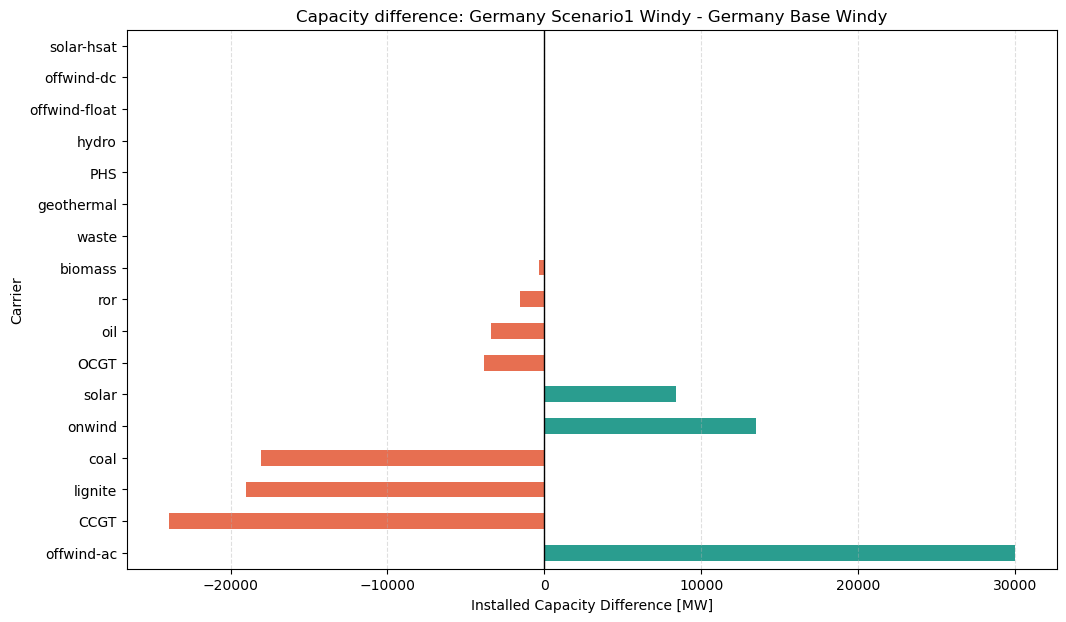

In [5]:
capacity_left = capacity_by_carrier(n_left)
capacity_right = capacity_by_carrier(n_right)
capacity_table = pd.DataFrame({
    f"{n_left.name}": capacity_left,
    f"{n_right.name}": capacity_right,
}).fillna(0.0)
capacity_table["Difference"] = capacity_table.iloc[:, 1] - capacity_table.iloc[:, 0]
capacity_table = capacity_table.reindex(capacity_table["Difference"].abs().sort_values(ascending=False).index)

fig, ax = plt.subplots(figsize=(12, 7))
bar_colors = np.where(capacity_table["Difference"] >= 0, "#2a9d8f", "#e76f51")
capacity_table["Difference"].plot(kind="barh", ax=ax, color=bar_colors)
ax.axvline(0, color="black", lw=1)
ax.set_title(f"Capacity difference: {n_right.name} - {n_left.name}")
ax.set_xlabel("Installed Capacity Difference [MW]")
ax.set_ylabel("Carrier")
ax.grid(axis="x", linestyle="--", alpha=0.4)
save_fig(fig, "01_capacity_difference.png")

log_print("\n=== Capacity Difference ===")
log_print(capacity_table.to_string())
log_print("\n")

### Grid congestion and marginal price difference


=== Marginal Price Difference ===
Selected snapshot: 2025-10-26 18:00:00
count    1350.000000
mean       -8.081072
std         9.257886
min       -35.834936
25%       -15.193227
50%        -5.672515
75%        -0.000108
max        19.010182
Line-loading difference stats:
count    628.000000
mean       0.043977
std        0.100005
min       -0.560991
25%       -0.003918
50%        0.036901
75%        0.091713
max        0.445111
Saved figure: /home/lucakristin/Desktop/my_pypsa/pypsa-eur/comparison/germany_base_windy_germany_scenario1_windy/02_price_and_loading_difference.png




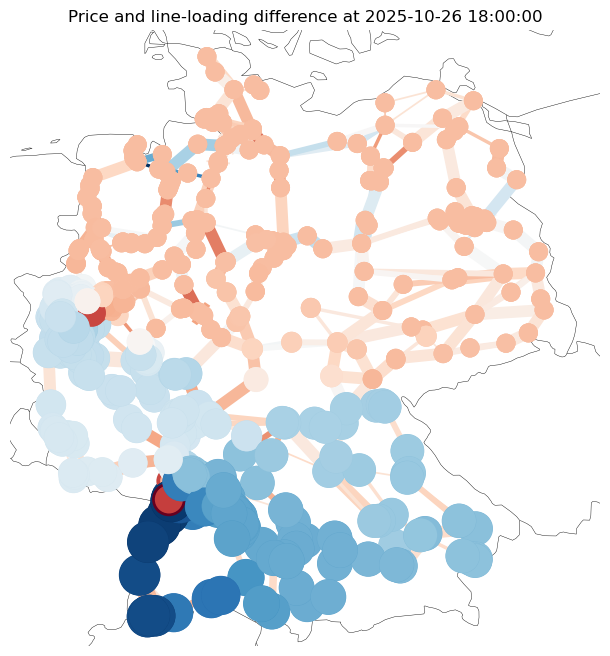

In [27]:
price_delta = n_right.buses_t.marginal_price.sub(n_left.buses_t.marginal_price, fill_value=0.0)
peak_snapshot = price_delta.abs().mean(axis=1).idxmax()
bus_delta = align_series(price_delta.loc[peak_snapshot], n_left.buses.index)
line_delta = align_series(line_loading_series(n_right).sub(line_loading_series(n_left), fill_value=0.0), n_left.lines.index)

fig, ax = plt.subplots(figsize=(13, 8), subplot_kw={"projection": ccrs.EqualEarth()})
n_left.plot(
    ax=ax,
    geomap=True,
    title=f"Price and line-loading difference at {peak_snapshot}",
    bus_sizes=rescale_absolute(bus_delta),
    bus_colors=bus_delta,
    bus_cmap="RdBu_r",
    line_colors=line_delta,
    line_cmap="RdBu_r",
    line_width=align_series(line_capacity_series(n_left), n_left.lines.index) / 400,
    link_width=align_series(link_capacity_series(n_left), n_left.links.index) / 400 if not n_left.links.empty else 0,
)

log_print("\n=== Marginal Price Difference ===")
log_print(f"Selected snapshot: {peak_snapshot}")
log_print(bus_delta.describe().to_string())
log_print("Line-loading difference stats:")
log_print(line_delta.describe().to_string())
save_fig(fig, "02_price_and_loading_difference.png")
log_print("\n")

### Load shedding difference


=== Load Shedding Difference ===


FileNotFoundError: [Errno 2] No such file or directory: ''

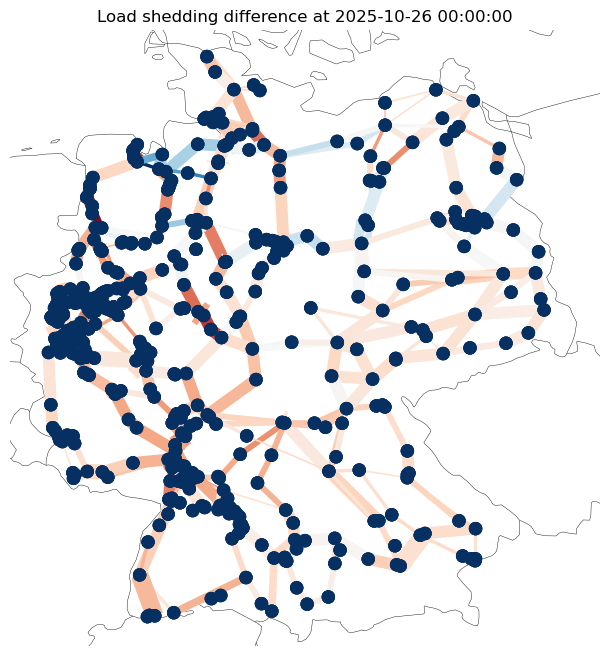

In [20]:
shed_left = load_shedding_by_bus(n_left)
shed_right = load_shedding_by_bus(n_right)
shed_delta = shed_right.sub(shed_left, fill_value=0.0)
worst_snapshot = shed_delta.abs().sum(axis=1).idxmax()
bus_delta = align_series(shed_delta.loc[worst_snapshot], n_left.buses.index)

fig, ax = plt.subplots(figsize=(13, 8), subplot_kw={"projection": ccrs.EqualEarth()})
n_left.plot(
    ax=ax,
    geomap=True,
    title=f"Load shedding difference at {worst_snapshot}",
    bus_sizes=rescale_absolute(bus_delta, base=0.01, span=0.12),
    bus_colors=bus_delta,
    bus_cmap="RdBu_r",
    line_colors=align_series(line_loading_series(n_right).sub(line_loading_series(n_left), fill_value=0.0), n_left.lines.index),
    line_cmap="RdBu_r",
    line_width=align_series(line_capacity_series(n_left), n_left.lines.index) / 400,
    link_width=align_series(link_capacity_series(n_left), n_left.links.index) / 400 if not n_left.links.empty else 0,
)

log_print("\n=== Load Shedding Difference ===")
log_print(f"Worst snapshot: {worst_snapshot}")
log_print(bus_delta.describe().to_string())
log_print("Total shed difference [MW]:", shed_delta.sum().sum())
save_fig(fig, "03_load_shedding_difference.png")
log_print("\n")

### Offshore wind curtailment difference

Carrier: offwind-ac


FileNotFoundError: [Errno 2] No such file or directory: ''

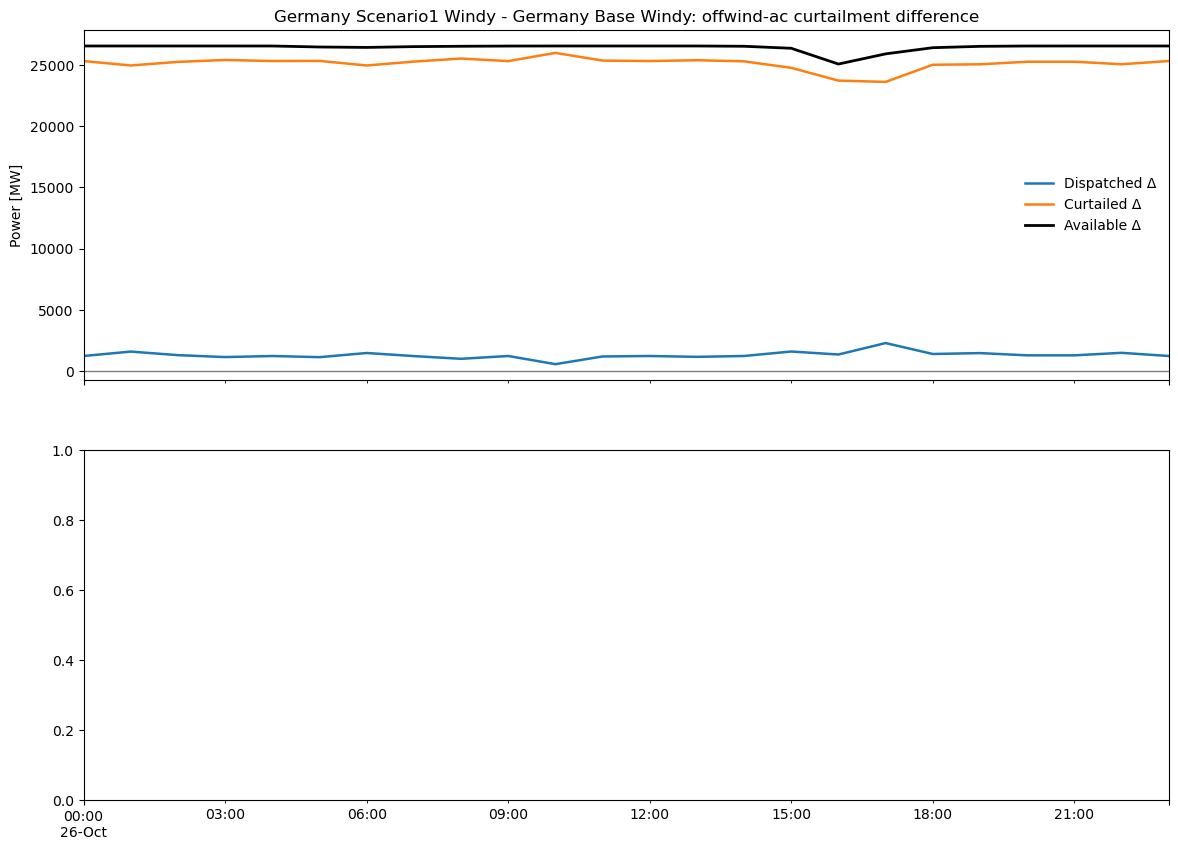

In [21]:
def plot_curtailment_difference(left, right, carrier, ax):
    available_left, dispatch_left, curtailed_left = carrier_curtailment(left)
    available_right, dispatch_right, curtailed_right = carrier_curtailment(right)

    comparison = pd.DataFrame({
        "Available Δ": available_right[carrier].sub(available_left[carrier], fill_value=0.0),
        "Dispatched Δ": dispatch_right[carrier].sub(dispatch_left[carrier], fill_value=0.0),
        "Curtailed Δ": curtailed_right[carrier].sub(curtailed_left[carrier], fill_value=0.0),
    })

    comparison[["Dispatched Δ", "Curtailed Δ"]].plot(ax=ax, lw=1.8)
    comparison["Available Δ"].plot(ax=ax, color="black", lw=2, label="Available Δ")
    ax.axhline(0, color="black", lw=1, alpha=0.5)
    ax.set_xlabel("")
    ax.set_ylabel("Power [MW]")
    ax.set_title(f"{right.name} - {left.name}: {carrier} curtailment difference")
    ax.legend(frameon=False)

    log_print(f"Carrier: {carrier}")
    log_print(comparison.sum().to_string())

fig, axes = plt.subplots(2, 1, figsize=(14, 10), sharex=True)
plot_curtailment_difference(n_left, n_right, "offwind-ac", axes[0])
plot_curtailment_difference(n_left, n_right, "onwind", axes[1])
save_fig(fig, "04_wind_curtailment_difference.png")

### Dispatch and total energy difference

Saved figure: 05_dispatch_difference.png


FileNotFoundError: [Errno 2] No such file or directory: ''

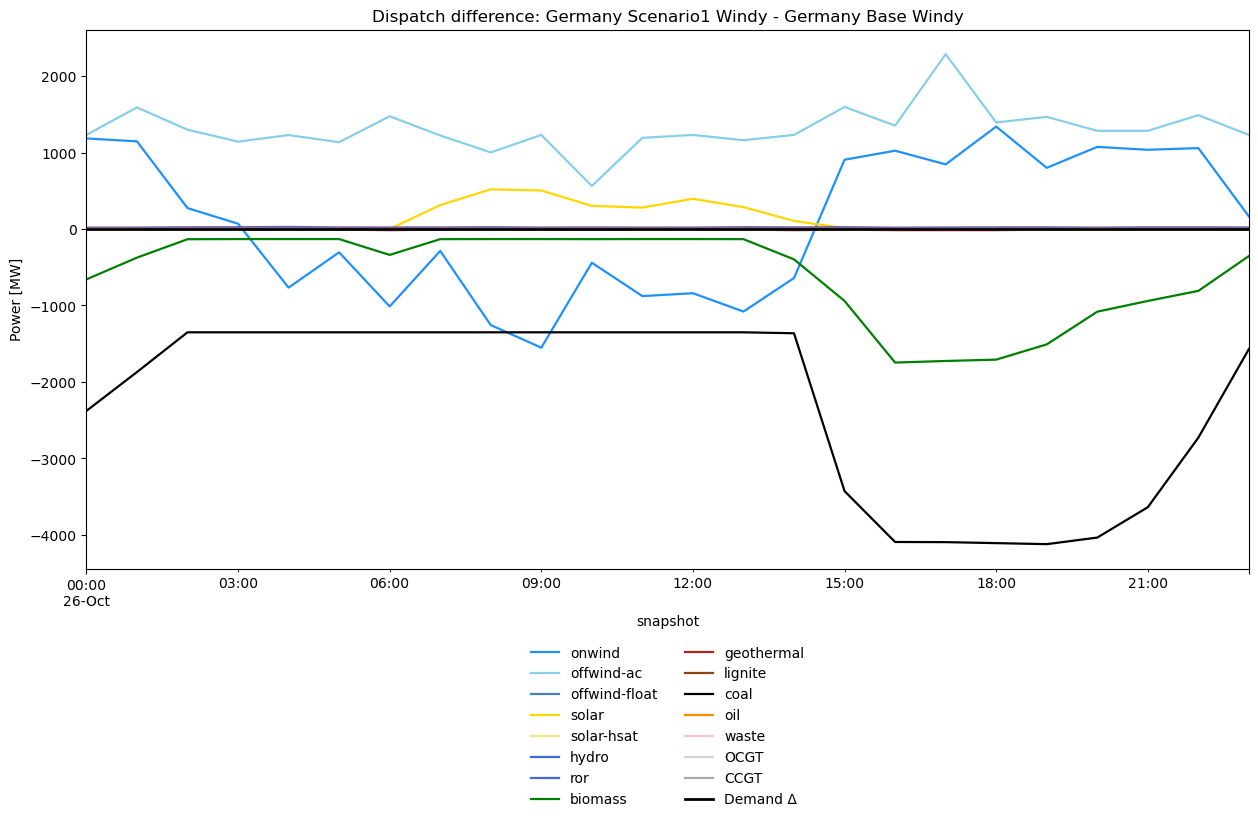

In [22]:
colors = {
    "onwind": "dodgerblue",
    "offwind-ac": "skyblue",
    "offwind-float": "steelblue",
    "solar": "gold",
    "solar-hsat": "khaki",
    "hydro": "royalblue",
    "ror": "royalblue",
    "lignite": "saddlebrown",
    "coal": "black",
    "oil": "darkorange",
    "OCGT": "lightgray",
    "CCGT": "darkgray",
    "biomass": "green",
    "waste": "pink",
    "geothermal": "firebrick",
}

carrier_order = [
    "onwind", "offwind-ac", "offwind-float",
    "solar", "solar-hsat",
    "hydro", "ror",
    "biomass", "geothermal",
    "lignite", "coal", "oil", "waste",
    "OCGT", "CCGT",
]

dispatch_left = carrier_dispatch(n_left)
dispatch_right = carrier_dispatch(n_right)
dispatch_delta = dispatch_right.sub(dispatch_left, fill_value=0.0).reindex(columns=carrier_order).fillna(0.0)
demand_delta = n_right.loads_t.p_set.sum(axis=1).sub(n_left.loads_t.p_set.sum(axis=1), fill_value=0.0)

fig, ax = plt.subplots(figsize=(15, 7))
dispatch_delta.plot(ax=ax, lw=1.6, color=[colors.get(col, "gray") for col in dispatch_delta.columns])
demand_delta.plot(ax=ax, color="black", lw=2, label="Demand Δ")
ax.set_title(f"Dispatch difference: {n_right.name} - {n_left.name}")
ax.set_ylabel("Power [MW]")
ax.legend(ncol=2, loc="upper center", bbox_to_anchor=(0.5, -0.12), frameon=False)
save_fig(fig, "05_dispatch_difference.png")

energy_left = dispatch_left.sum().reindex(carrier_order).fillna(0.0)
energy_right = dispatch_right.sum().reindex(carrier_order).fillna(0.0)
energy_table = pd.DataFrame({
    f"{n_left.name}": energy_left,
    f"{n_right.name}": energy_right,
}).fillna(0.0)
energy_table["Difference"] = energy_table.iloc[:, 1] - energy_table.iloc[:, 0]
energy_table = energy_table.reindex(energy_table["Difference"].abs().sort_values(ascending=False).index)

fig, ax = plt.subplots(figsize=(12, 7))
energy_table["Difference"].div(1e6).plot(kind="barh", ax=ax, color=np.where(energy_table["Difference"] >= 0, "#2a9d8f", "#e76f51"))
ax.axvline(0, color="black", lw=1)
ax.set_title(f"Total energy difference: {n_right.name} - {n_left.name}")
ax.set_xlabel("Energy Difference [TWh]")
ax.set_ylabel("Carrier")
ax.grid(axis="x", linestyle="--", alpha=0.4)
save_fig(fig, "06_energy_difference.png")

log_print("\n=== Dispatch Difference ===")
log_print(dispatch_delta.sum().to_string())
log_print("\n=== Energy Difference ===")
log_print(energy_table.to_string())
log_print("\n")

### Emissions and summary statistics

Saved figure: /home/lucakristin/Desktop/my_pypsa/pypsa-eur/analysis/germany_base_windy_vs_germany_scenario1_windy/07_emissions_difference.png
Saved figure: /home/lucakristin/Desktop/my_pypsa/pypsa-eur/analysis/germany_base_windy_vs_germany_scenario1_windy/08_summary_statistics_difference.png

=== Emissions Difference ===
Germany Base Windy         41140.114777
Germany Scenario1 Windy       82.702940
Difference                -41057.411837

=== Summary Statistics Difference ===
                Germany Base Windy  Germany Scenario1 Windy    Difference
buses                 1.350000e+03             1.350000e+03      0.000000
lines                 6.280000e+02             6.280000e+02      0.000000
links                 1.800000e+03             1.800000e+03      0.000000
generators            3.242000e+03             3.242000e+03      0.000000
loads                 4.500000e+02             4.500000e+02      0.000000
storage_units         6.000000e+01             6.000000e+01      0.000000


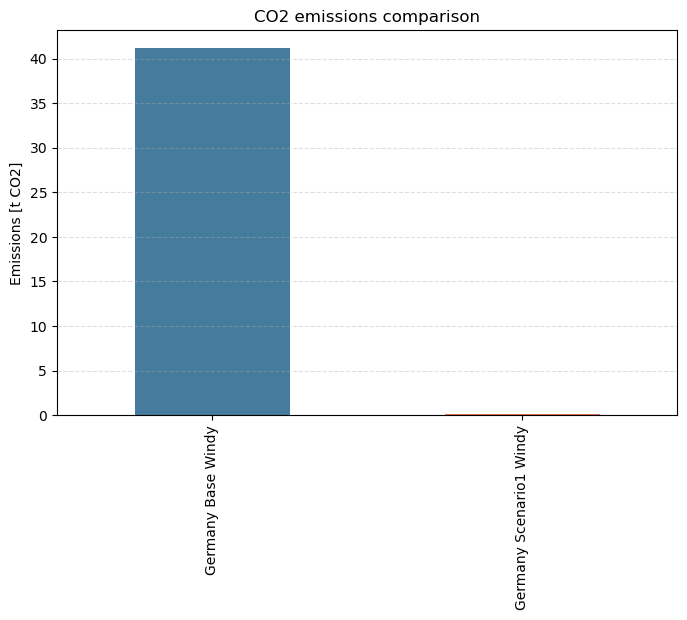

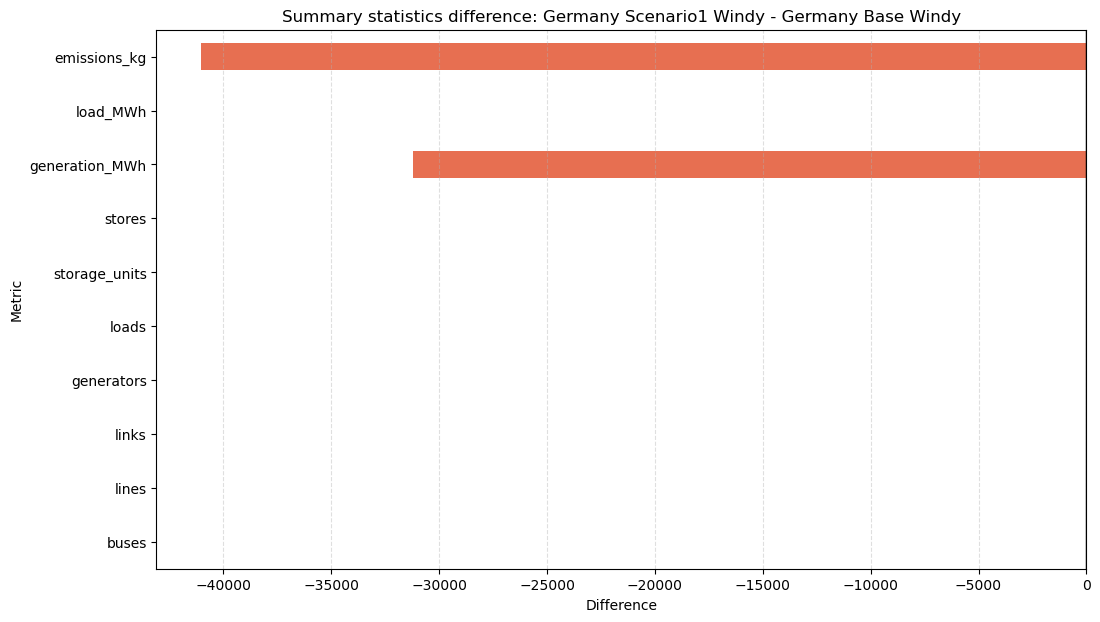

In [12]:
emissions_left = calculate_emissions(n_left)
emissions_right = calculate_emissions(n_right)
emissions_table = pd.Series({
    f"{n_left.name}": emissions_left,
    f"{n_right.name}": emissions_right,
    "Difference": emissions_right - emissions_left,
})

fig, ax = plt.subplots(figsize=(8, 5))
emissions_table[[f"{n_left.name}", f"{n_right.name}"]].div(1e3).plot(kind="bar", ax=ax, color=["#457b9d", "#e76f51"])
ax.set_title("CO2 emissions comparison")
ax.set_ylabel("Emissions [t CO2]")
ax.grid(axis="y", linestyle="--", alpha=0.4)
save_fig(fig, "07_emissions_difference.png")

summary_table = pd.DataFrame({
    f"{n_left.name}": network_summary(n_left),
    f"{n_right.name}": network_summary(n_right),
}).fillna(0.0)
summary_table["Difference"] = summary_table.iloc[:, 1] - summary_table.iloc[:, 0]

fig, ax = plt.subplots(figsize=(12, 7))
summary_table["Difference"].plot(kind="barh", ax=ax, color=np.where(summary_table["Difference"] >= 0, "#2a9d8f", "#e76f51"))
ax.axvline(0, color="black", lw=1)
ax.set_title(f"Summary statistics difference: {n_right.name} - {n_left.name}")
ax.set_xlabel("Difference")
ax.set_ylabel("Metric")
ax.grid(axis="x", linestyle="--", alpha=0.4)
save_fig(fig, "08_summary_statistics_difference.png")

log_print("\n=== Emissions Difference ===")
log_print(emissions_table.to_string())
log_print("\n=== Summary Statistics Difference ===")
log_print(summary_table.to_string())
log_print("\n=== Analysis Complete ===")
log_print(f"All results saved to: {analysis_dir}")